In [4]:
import os
import cv2
import numpy as np
from imutils import paths
from sklearn.model_selection import StratifiedGroupKFold
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy
import math

# -------------------------------------------------
# Device Configuration
# -------------------------------------------------
print(f"Number of GPUs available: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}\n')

# -------------------------------------------------
# Hyperparameters (stronger regularization for hard folds)
# -------------------------------------------------
batch_size = 32
num_epochs = 30
learning_rate = 2e-4
weight_decay = 5e-4
img_rows, img_cols = 128, 128
n_folds = 5
early_stop_patience = 7
min_epochs = 6
dropout_p = 0.55
spatial_dropout_p = 0.30

# -------------------------------------------------
# Paths
# -------------------------------------------------
control_folder = r'C:\Users\RTX2080Ti\Desktop\Dyslexia DL\FCM\control'
dyslexia_folder = r'C:\Users\RTX2080Ti\Desktop\Dyslexia DL\FCM\dyslexia'

# -------------------------------------------------
# Load data (group-aware)
# -------------------------------------------------
def load_images_from_folder(folder, label):
    data = []
    for imagePath in paths.list_images(folder):
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (img_cols, img_rows))
        filename = os.path.basename(imagePath)
        group_id = filename.split('_')[0]
        data.append((image, label, group_id))
    return data

control_data = load_images_from_folder(control_folder, 0)
dyslexia_data = load_images_from_folder(dyslexia_folder, 1)
data = control_data + dyslexia_data
np.random.seed(42)
np.random.shuffle(data)

X = np.array([d[0] for d in data], dtype=np.float32)
y = np.array([d[1] for d in data], dtype=np.float32)
groups = np.array([d[2] for d in data])
X /= 255.0

print(f"Total samples: {len(X)} (Control: {(y==0).sum()}, Dyslexia: {(y==1).sum()})")
print(f"Total unique groups/subjects detected: {len(np.unique(groups))}")

# -------------------------------------------------
# Improved CNN Model with BatchNorm
# -------------------------------------------------
class CNNModel(nn.Module):
    def __init__(self, img_rows=128, img_cols=128, dropout_p=0.55, spatial_dropout_p=0.30):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)

        self.dropout_spatial = nn.Dropout2d(spatial_dropout_p)

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        self.conv5 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(32)

        self.flat_features = 32 * (img_rows // 4) * (img_cols // 4)

        self.fc1 = nn.Linear(self.flat_features, 64)
        self.bn_fc = nn.BatchNorm1d(64)
        self.dropout_fc = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout_spatial(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool(x)
        x = self.dropout_spatial(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.dropout_fc(x)
        x = torch.sigmoid(self.fc2(x))
        return x

# -------------------------------------------------
# Stronger on-the-fly augmentation (train only)
# -------------------------------------------------
def augment_batch(x):
    """x: (B, C, H, W) on device, values in [0, 1]"""
    B = x.size(0)

    # Horizontal flip
    if torch.rand(1, device=x.device) < 0.5:
        x = torch.flip(x, dims=[-1])

    # Small random rotation (±12 degrees)
    if torch.rand(1, device=x.device) < 0.5:
        angle = (torch.rand(1, device=x.device).item() * 24 - 12)
        angle_rad = math.radians(angle)
        theta = torch.tensor([
            [math.cos(angle_rad), -math.sin(angle_rad), 0],
            [math.sin(angle_rad),  math.cos(angle_rad), 0]
        ], dtype=torch.float32, device=x.device).unsqueeze(0).repeat(B, 1, 1)
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        x = F.grid_sample(x, grid, align_corners=False, mode='bilinear', padding_mode='border')

    # Brightness / contrast
    scale = 0.70 + 0.60 * torch.rand(1, device=x.device)
    x = (x * scale).clamp(0.0, 1.0)

    # Small brightness shift
    shift = 0.12 * (torch.rand(1, device=x.device) - 0.5)
    x = (x + shift).clamp(0.0, 1.0)

    # Mild Gaussian noise
    if torch.rand(1, device=x.device) < 0.40:
        noise = torch.randn_like(x) * 0.03
        x = (x + noise).clamp(0.0, 1.0)

    return x

# -------------------------------------------------
# Mixup helpers
# -------------------------------------------------
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# -------------------------------------------------
# CutMix helpers
# -------------------------------------------------
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def cutmix_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]

    # adjust lambda to exactly match pixel ratio
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size()[-1] * x.size()[-2]))
    y_a, y_b = y, y[index]
    return x, y_a, y_b, lam

def cutmix_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# -------------------------------------------------
# Convert data to tensors
# -------------------------------------------------
X_t = torch.tensor(X).permute(0, 3, 1, 2).float()
y_t = torch.tensor(y).float().unsqueeze(1)

# For Out-of-Fold evaluation
oof_true = np.zeros(len(y_t))
oof_prob = np.zeros(len(y_t))

# -------------------------------------------------
# 5-Fold Stratified Group Cross-Validation
# -------------------------------------------------
sgkf = StratifiedGroupKFold(n_splits=n_folds)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups), 1):
    print(f"\n{'='*60}")
    print(f"FOLD {fold}/{n_folds}")
    print(f"{'='*60}")

    X_tr = X_t[train_idx]
    y_tr = y_t[train_idx]
    X_va = X_t[val_idx]
    y_va = y_t[val_idx]

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=batch_size, shuffle=False)

    model = CNNModel(img_rows=img_rows, img_cols=img_cols,
                     dropout_p=dropout_p, spatial_dropout_p=spatial_dropout_p).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_fold_val_loss = float('inf')
    best_fold_val_acc  = 0.0
    best_fold_state    = None
    patience_counter   = 0

    for epoch in range(num_epochs):
        # -------------------- Train --------------------
        model.train()
        train_loss = 0.0
        train_correct = 0

        for data_batch, target in train_loader:
            data_batch = data_batch.to(device)
            target = target.to(device)

            # 1. Geometric / intensity augmentation
            data_batch = augment_batch(data_batch)

            # 2. Randomly choose: Normal / Mixup / CutMix
            r = np.random.rand()
            if r < 0.35:          # 35% Mixup
                data_batch, targets_a, targets_b, lam = mixup_data(data_batch, target, alpha=0.2)
                output = model(data_batch)
                loss = mixup_criterion(criterion, output, targets_a, targets_b, lam)
                pred = (output > 0.5).float()
                if lam > 0.5:
                    train_correct += pred.eq(targets_a).sum().item()
                else:
                    train_correct += pred.eq(targets_b).sum().item()

            elif r < 0.70:        # 35% CutMix
                data_batch, targets_a, targets_b, lam = cutmix_data(data_batch, target, alpha=1.0)
                output = model(data_batch)
                loss = cutmix_criterion(criterion, output, targets_a, targets_b, lam)
                pred = (output > 0.5).float()
                if lam > 0.5:
                    train_correct += pred.eq(targets_a).sum().item()
                else:
                    train_correct += pred.eq(targets_b).sum().item()

            else:                 # 30% Normal
                output = model(data_batch)
                loss = criterion(output, target)
                pred = (output > 0.5).float()
                train_correct += pred.eq(target).sum().item()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * data_batch.size(0)

        # -------------------- Validate --------------------
        model.eval()
        val_loss = 0.0
        correct = 0

        with torch.no_grad():
            for data_batch, target in val_loader:
                data_batch = data_batch.to(device)
                target = target.to(device)
                output = model(data_batch)
                val_loss += criterion(output, target).item() * data_batch.size(0)
                pred = (output > 0.5).float()
                correct += pred.eq(target).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc   = train_correct / len(train_loader.dataset)
        val_loss   /= len(val_loader.dataset)
        accuracy    = correct / len(val_loader.dataset)

        scheduler.step()

        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {accuracy:.4f}")

        # -------------------- Early stopping & checkpoint --------------------
        if val_loss < best_fold_val_loss:
            best_fold_val_loss = val_loss
            best_fold_val_acc  = accuracy
            best_fold_state    = copy.deepcopy(model.state_dict())
            patience_counter   = 0
        else:
            if (epoch + 1) >= min_epochs:
                patience_counter += 1
                if patience_counter >= early_stop_patience:
                    print(f" → Early stopping triggered by validation loss at epoch {epoch+1}")
                    break

    # Restore best weights for this fold
    if best_fold_state is not None:
        model.load_state_dict(best_fold_state)

    # ----- Collect Out-of-Fold predictions -----
    model.eval()
    with torch.no_grad():
        val_loader_oof = DataLoader(TensorDataset(X_va, y_va), batch_size=64, shuffle=False)
        probs = []
        for data_batch, _ in val_loader_oof:
            data_batch = data_batch.to(device)
            output = model(data_batch).cpu().numpy().ravel()
            probs.extend(output)

    oof_true[val_idx] = y_va.numpy().ravel()
    oof_prob[val_idx] = np.array(probs)

    fold_results.append({
        "fold": fold,
        "val_loss": best_fold_val_loss,
        "val_acc": best_fold_val_acc
    })

# -------------------------------------------------
# CV Summary
# -------------------------------------------------
print("\n" + "="*60)
print(f"{n_folds}-FOLD CROSS-VALIDATION SUMMARY")
print("="*60)
for res in fold_results:
    print(f"Fold {res['fold']} | Val Loss: {res['val_loss']:.4f} | Val Acc: {res['val_acc']:.4f}")

val_accs   = np.array([r["val_acc"] for r in fold_results])
val_losses = np.array([r["val_loss"] for r in fold_results])

print("-"*60)
print(f"Mean Validation Accuracy: {val_accs.mean():.4f} (+/- {val_accs.std():.4f})")
print(f"Mean Validation Loss: {val_losses.mean():.4f}")
print("="*60)

Number of GPUs available: 2
GPU 0: NVIDIA GeForce RTX 2080 Ti
GPU 1: NVIDIA GeForce RTX 2080 Ti
Using device: cuda:1

Total samples: 7982 (Control: 4566, Dyslexia: 3416)
Total unique groups/subjects detected: 52

FOLD 1/5
Epoch  1/30 | Train Loss: 0.6687 | Train Acc: 0.5979 | Val Loss: 0.5887 | Val Acc: 0.7237
Epoch  2/30 | Train Loss: 0.5290 | Train Acc: 0.7628 | Val Loss: 0.4372 | Val Acc: 0.7668
Epoch  3/30 | Train Loss: 0.4038 | Train Acc: 0.8602 | Val Loss: 0.3073 | Val Acc: 0.8596
Epoch  4/30 | Train Loss: 0.3586 | Train Acc: 0.8859 | Val Loss: 0.3008 | Val Acc: 0.8596
Epoch  5/30 | Train Loss: 0.3364 | Train Acc: 0.8961 | Val Loss: 0.2481 | Val Acc: 0.8811
Epoch  6/30 | Train Loss: 0.3396 | Train Acc: 0.8924 | Val Loss: 0.2660 | Val Acc: 0.8850
Epoch  7/30 | Train Loss: 0.2887 | Train Acc: 0.9194 | Val Loss: 0.1908 | Val Acc: 0.9295
Epoch  8/30 | Train Loss: 0.3057 | Train Acc: 0.9146 | Val Loss: 0.1638 | Val Acc: 0.9412
Epoch  9/30 | Train Loss: 0.2834 | Train Acc: 0.9242 | Val

OUT-OF-FOLD (5-FOLD CV) PERFORMANCE
Accuracy  : 0.9719
Precision : 0.9801
Recall    : 0.9537
F1-Score  : 0.9668
ROC-AUC   : 0.9971
PR-AUC    : 0.9963

Classification Report:
              precision    recall  f1-score   support

     Control       0.97      0.99      0.98      4566
    Dyslexia       0.98      0.95      0.97      3416

    accuracy                           0.97      7982
   macro avg       0.97      0.97      0.97      7982
weighted avg       0.97      0.97      0.97      7982



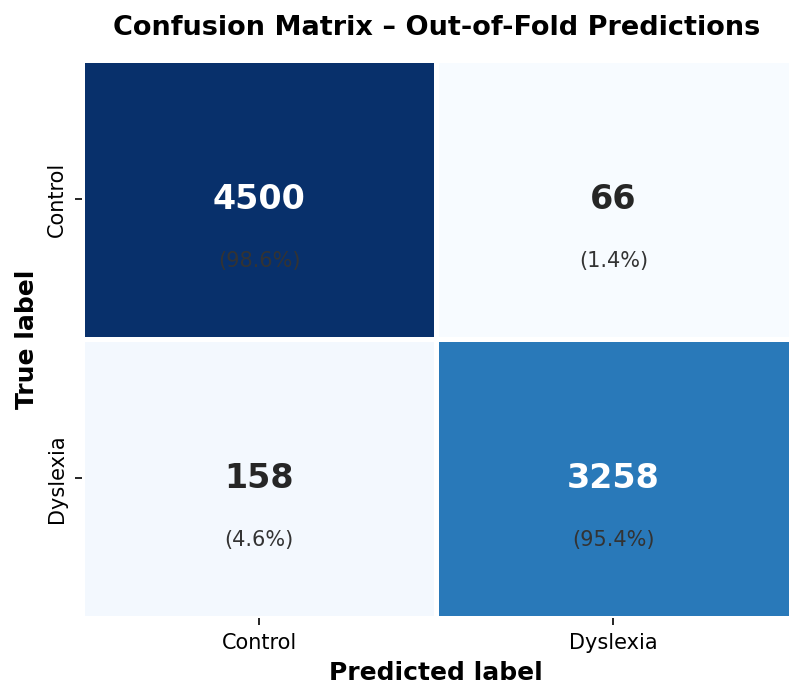

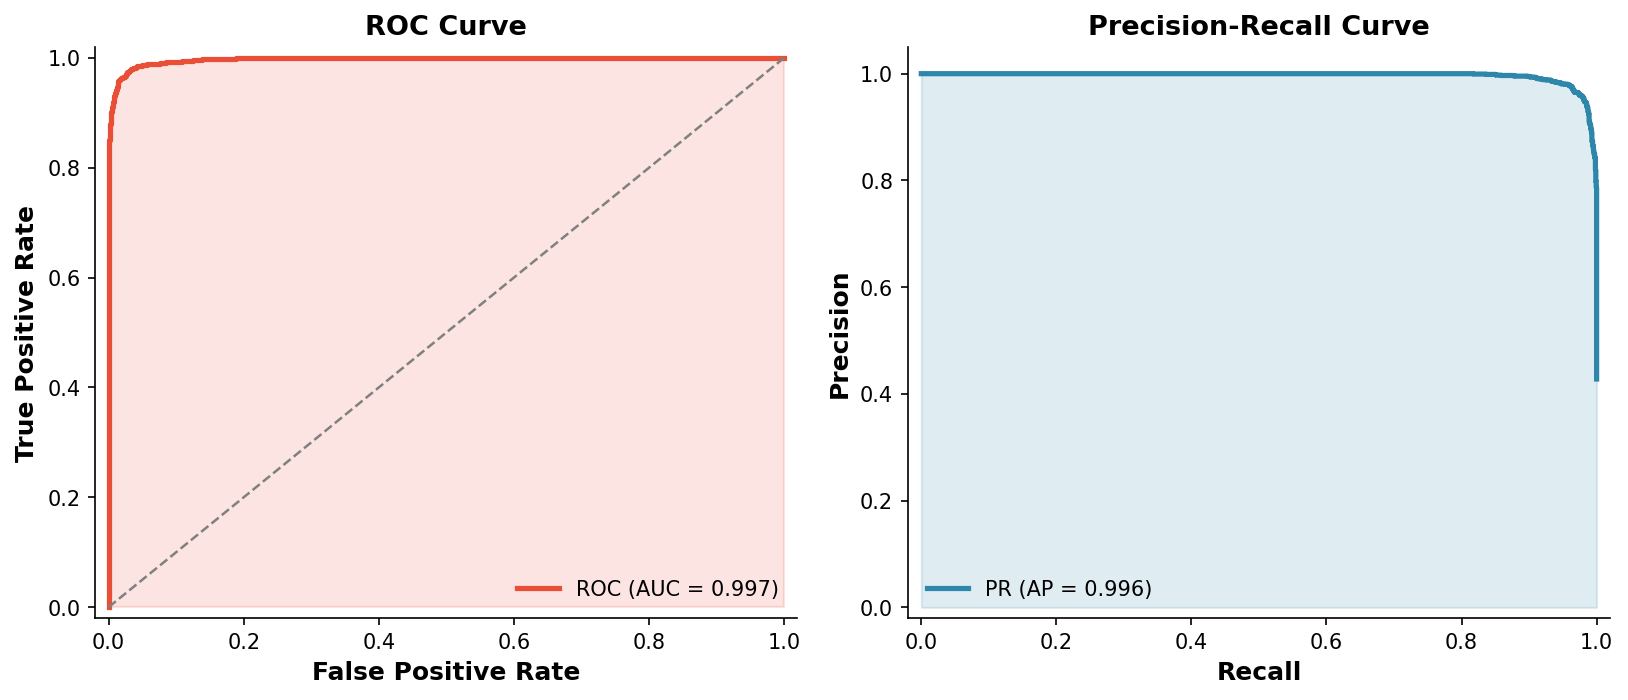

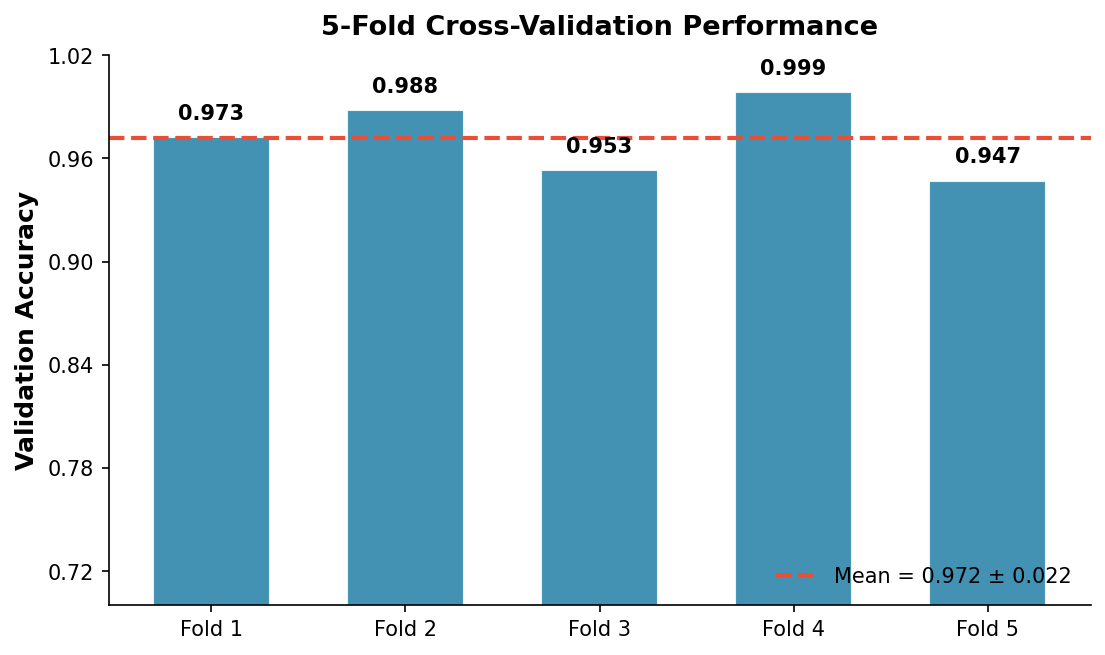

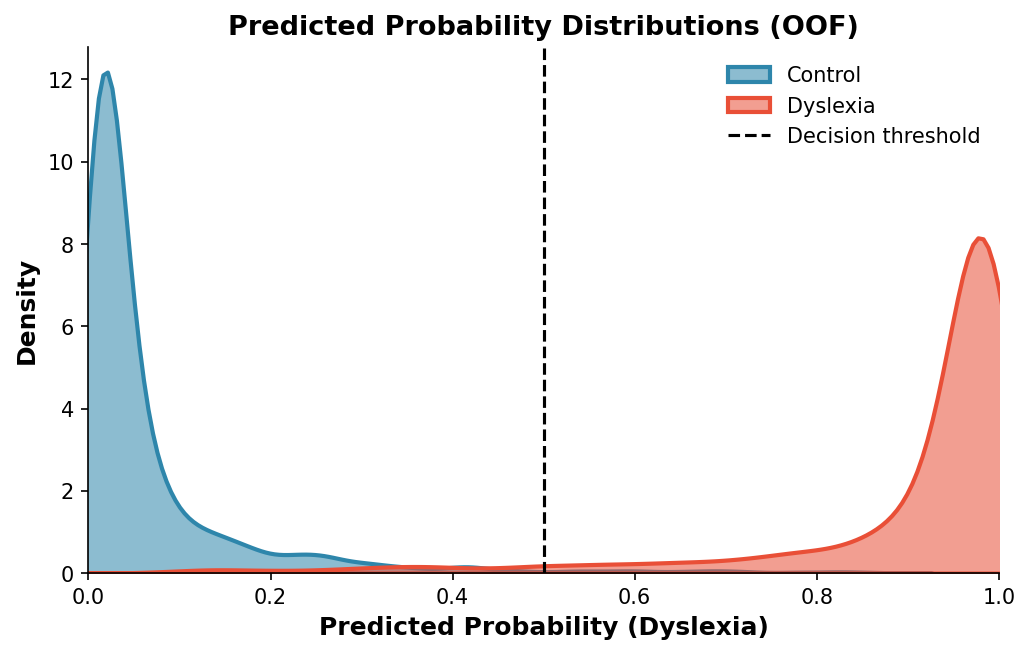

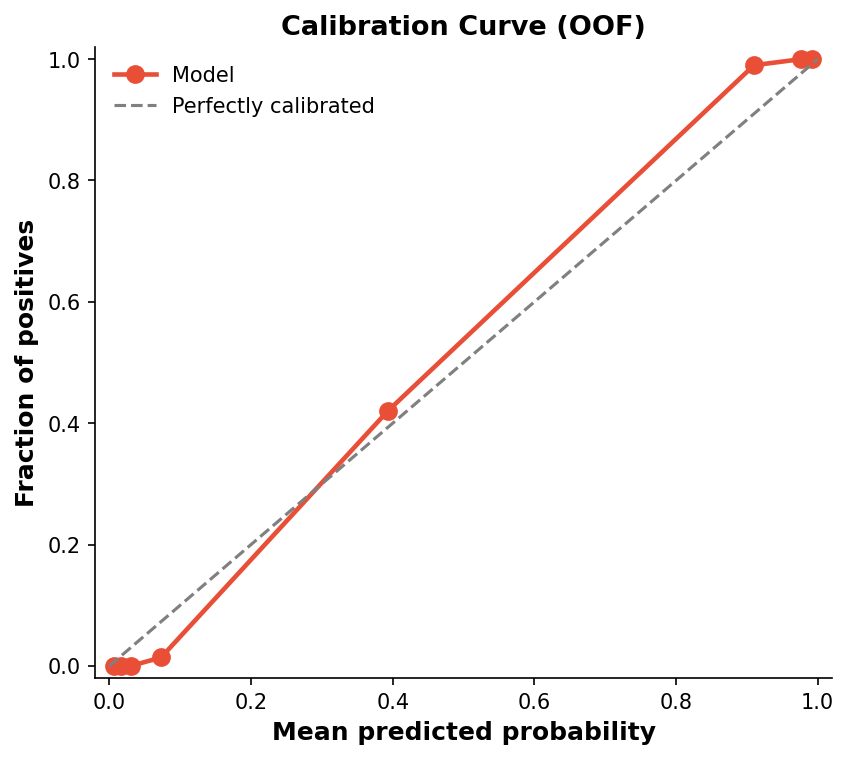

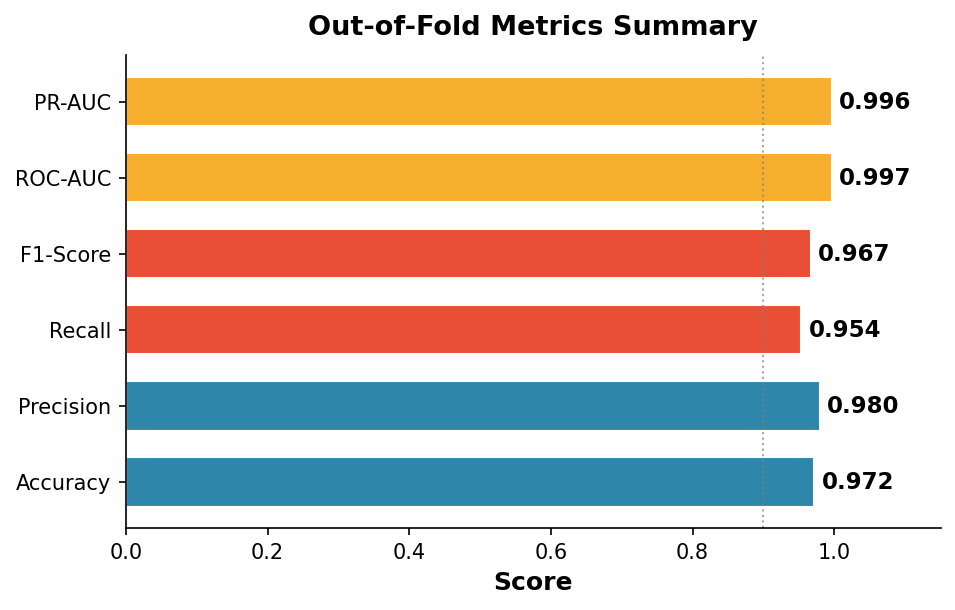


All figures saved as PNG (300 dpi) + PDF


In [5]:
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
import pandas as pd
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import matplotlib as mpl

# Defaults Parameters
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ============================================================
# OUT-OF-FOLD EVALUATION
# ============================================================
y_true = oof_true.astype(int)
y_prob = oof_prob
y_pred = (y_prob > 0.5).astype(int)

# -------------------------------------------------
# 1. Metrics summary
# -------------------------------------------------
acc     = accuracy_score(y_true, y_pred)
prec    = precision_score(y_true, y_pred)
rec     = recall_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)

print("="*55)
print("OUT-OF-FOLD (5-FOLD CV) PERFORMANCE")
print("="*55)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Control', 'Dyslexia']))

# -------------------------------------------------
# Color palette (color-blind friendly)
# -------------------------------------------------
colors = {
    'control': '#2E86AB',
    'dyslexia': '#E94F37',
    'accent': '#F6AE2D',
    'neutral': '#4A4A4A',
    'light': '#F5F5F5'
}

# ============================================================
# FIGURE 1 – Confusion Matrix
# ============================================================
fig, ax = plt.subplots(figsize=(5.5, 4.8))
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Control', 'Dyslexia'],
            yticklabels=['Control', 'Dyslexia'],
            cbar=False, linewidths=1.5, linecolor='white',
            annot_kws={"size": 16, "weight": "bold"}, ax=ax)

for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.72, f'({cm_norm[i,j]*100:.1f}%)',
                ha='center', va='center', fontsize=10, color='#333333')

ax.set_xlabel('Predicted label', fontweight='bold')
ax.set_ylabel('True label', fontweight='bold')
ax.set_title('Confusion Matrix – Out-of-Fold Predictions', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig1_confusion_matrix.png', dpi=300)
plt.savefig('fig1_confusion_matrix.pdf')
plt.show()

# ============================================================
# FIGURE 2 – ROC + Precision-Recall
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, color=colors['dyslexia'], lw=2.5,
             label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], ls='--', color='grey', lw=1.2)
axes[0].fill_between(fpr, tpr, alpha=0.15, color=colors['dyslexia'])
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right', frameon=False)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# PR
precision, recall, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(recall, precision, color=colors['control'], lw=2.5,
             label=f'PR (AP = {pr_auc:.3f})')
axes[1].fill_between(recall, precision, alpha=0.15, color=colors['control'])
axes[1].set_xlabel('Recall', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='lower left', frameon=False)
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.05])

plt.tight_layout()
plt.savefig('fig2_roc_pr_curves.png', dpi=300)
plt.savefig('fig2_roc_pr_curves.pdf')
plt.show()

# ============================================================
# FIGURE 3 – Cross-Validation Results
# ============================================================
fold_df = pd.DataFrame(fold_results)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(fold_df))
bars = ax.bar(x, fold_df['val_acc'], color=colors['control'],
              edgecolor='white', width=0.6, alpha=0.9)

mean_acc = fold_df['val_acc'].mean()
std_acc  = fold_df['val_acc'].std()
ax.axhline(mean_acc, color=colors['dyslexia'], ls='--', lw=2,
           label=f'Mean = {mean_acc:.3f} ± {std_acc:.3f}')

for bar, acc_val in zip(bars, fold_df['val_acc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{acc_val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in fold_df['fold']])
ax.set_ylabel('Validation Accuracy', fontweight='bold')
ax.set_title('5-Fold Cross-Validation Performance', fontweight='bold', pad=10)
ax.set_ylim(0.70, 1.02)
ax.legend(frameon=False, loc='lower right')
ax.yaxis.set_major_locator(MaxNLocator(6))
plt.tight_layout()
plt.savefig('fig3_cv_results.png', dpi=300)
plt.savefig('fig3_cv_results.pdf')
plt.show()

# ============================================================
# FIGURE 4 – Probability distribution
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.kdeplot(y_prob[y_true == 0], fill=True, color=colors['control'],
            alpha=0.55, label='Control', linewidth=2, ax=ax)
sns.kdeplot(y_prob[y_true == 1], fill=True, color=colors['dyslexia'],
            alpha=0.55, label='Dyslexia', linewidth=2, ax=ax)
ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Decision threshold')
ax.set_xlabel('Predicted Probability (Dyslexia)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Predicted Probability Distributions (OOF)', fontweight='bold')
ax.legend(frameon=False)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('fig4_prob_distributions.png', dpi=300)
plt.savefig('fig4_prob_distributions.pdf')
plt.show()

# ============================================================
# FIGURE 5 – Calibration curve
# ============================================================
fig, ax = plt.subplots(figsize=(5.8, 5.2))
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=8, strategy='quantile')
ax.plot(prob_pred, prob_true, 'o-', color=colors['dyslexia'], lw=2.2,
        markersize=8, label='Model')
ax.plot([0, 1], [0, 1], '--', color='grey', lw=1.5, label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability', fontweight='bold')
ax.set_ylabel('Fraction of positives', fontweight='bold')
ax.set_title('Calibration Curve (OOF)', fontweight='bold')
ax.legend(frameon=False)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig('fig5_calibration.png', dpi=300)
plt.savefig('fig5_calibration.pdf')
plt.show()

# ============================================================
# FIGURE 6 – Metrics summary
# ============================================================
metrics = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'ROC-AUC': roc_auc,
    'PR-AUC': pr_auc
}

fig, ax = plt.subplots(figsize=(6.5, 4.2))
names = list(metrics.keys())
values = list(metrics.values())
bars = ax.barh(names, values, color=[colors['control'], colors['control'],
                                     colors['dyslexia'], colors['dyslexia'],
                                     colors['accent'], colors['accent']],
               edgecolor='white', height=0.65)

for bar, val in zip(bars, values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Score', fontweight='bold')
ax.set_title('Out-of-Fold Metrics Summary', fontweight='bold', pad=10)
ax.axvline(0.9, color='grey', ls=':', lw=1, alpha=0.7)
plt.tight_layout()
plt.savefig('fig6_metrics_summary.png', dpi=300)
plt.savefig('fig6_metrics_summary.pdf')
plt.show()

print("\nAll figures saved as PNG (300 dpi) + PDF")

Correctly classified Control  : 4500
Correctly classified Dyslexic : 3258
Computing averaged Grad-CAM++ maps

Processing 100 Control samples …
  Control: 20/100 processed
  Control: 40/100 processed
  Control: 60/100 processed
  Control: 80/100 processed
  Control: 100/100 processed
  Control: finished (100 successful CAMs)

Processing 100 Dyslexic samples …
  Dyslexic: 20/100 processed
  Dyslexic: 40/100 processed
  Dyslexic: 60/100 processed
  Dyslexic: 80/100 processed
  Dyslexic: 100/100 processed
  Dyslexic: finished (100 successful CAMs)
Hooks removed.

Extracting discriminative channel pairs

Top 30 pairs — CONTROL
Rank   Ch_i     Ch_j     Mean CAM  
------------------------------------
1      E14      E37      0.9833
2      E13      E36      0.9695
3      E17      E35      0.8272
4      E13      E37      0.8192
5      E13      E35      0.8116
6      E15      E38      0.7820
7      E116     E125     0.7805
8      E20      E63      0.7565
9      E14      E38      0.7389
10     E1

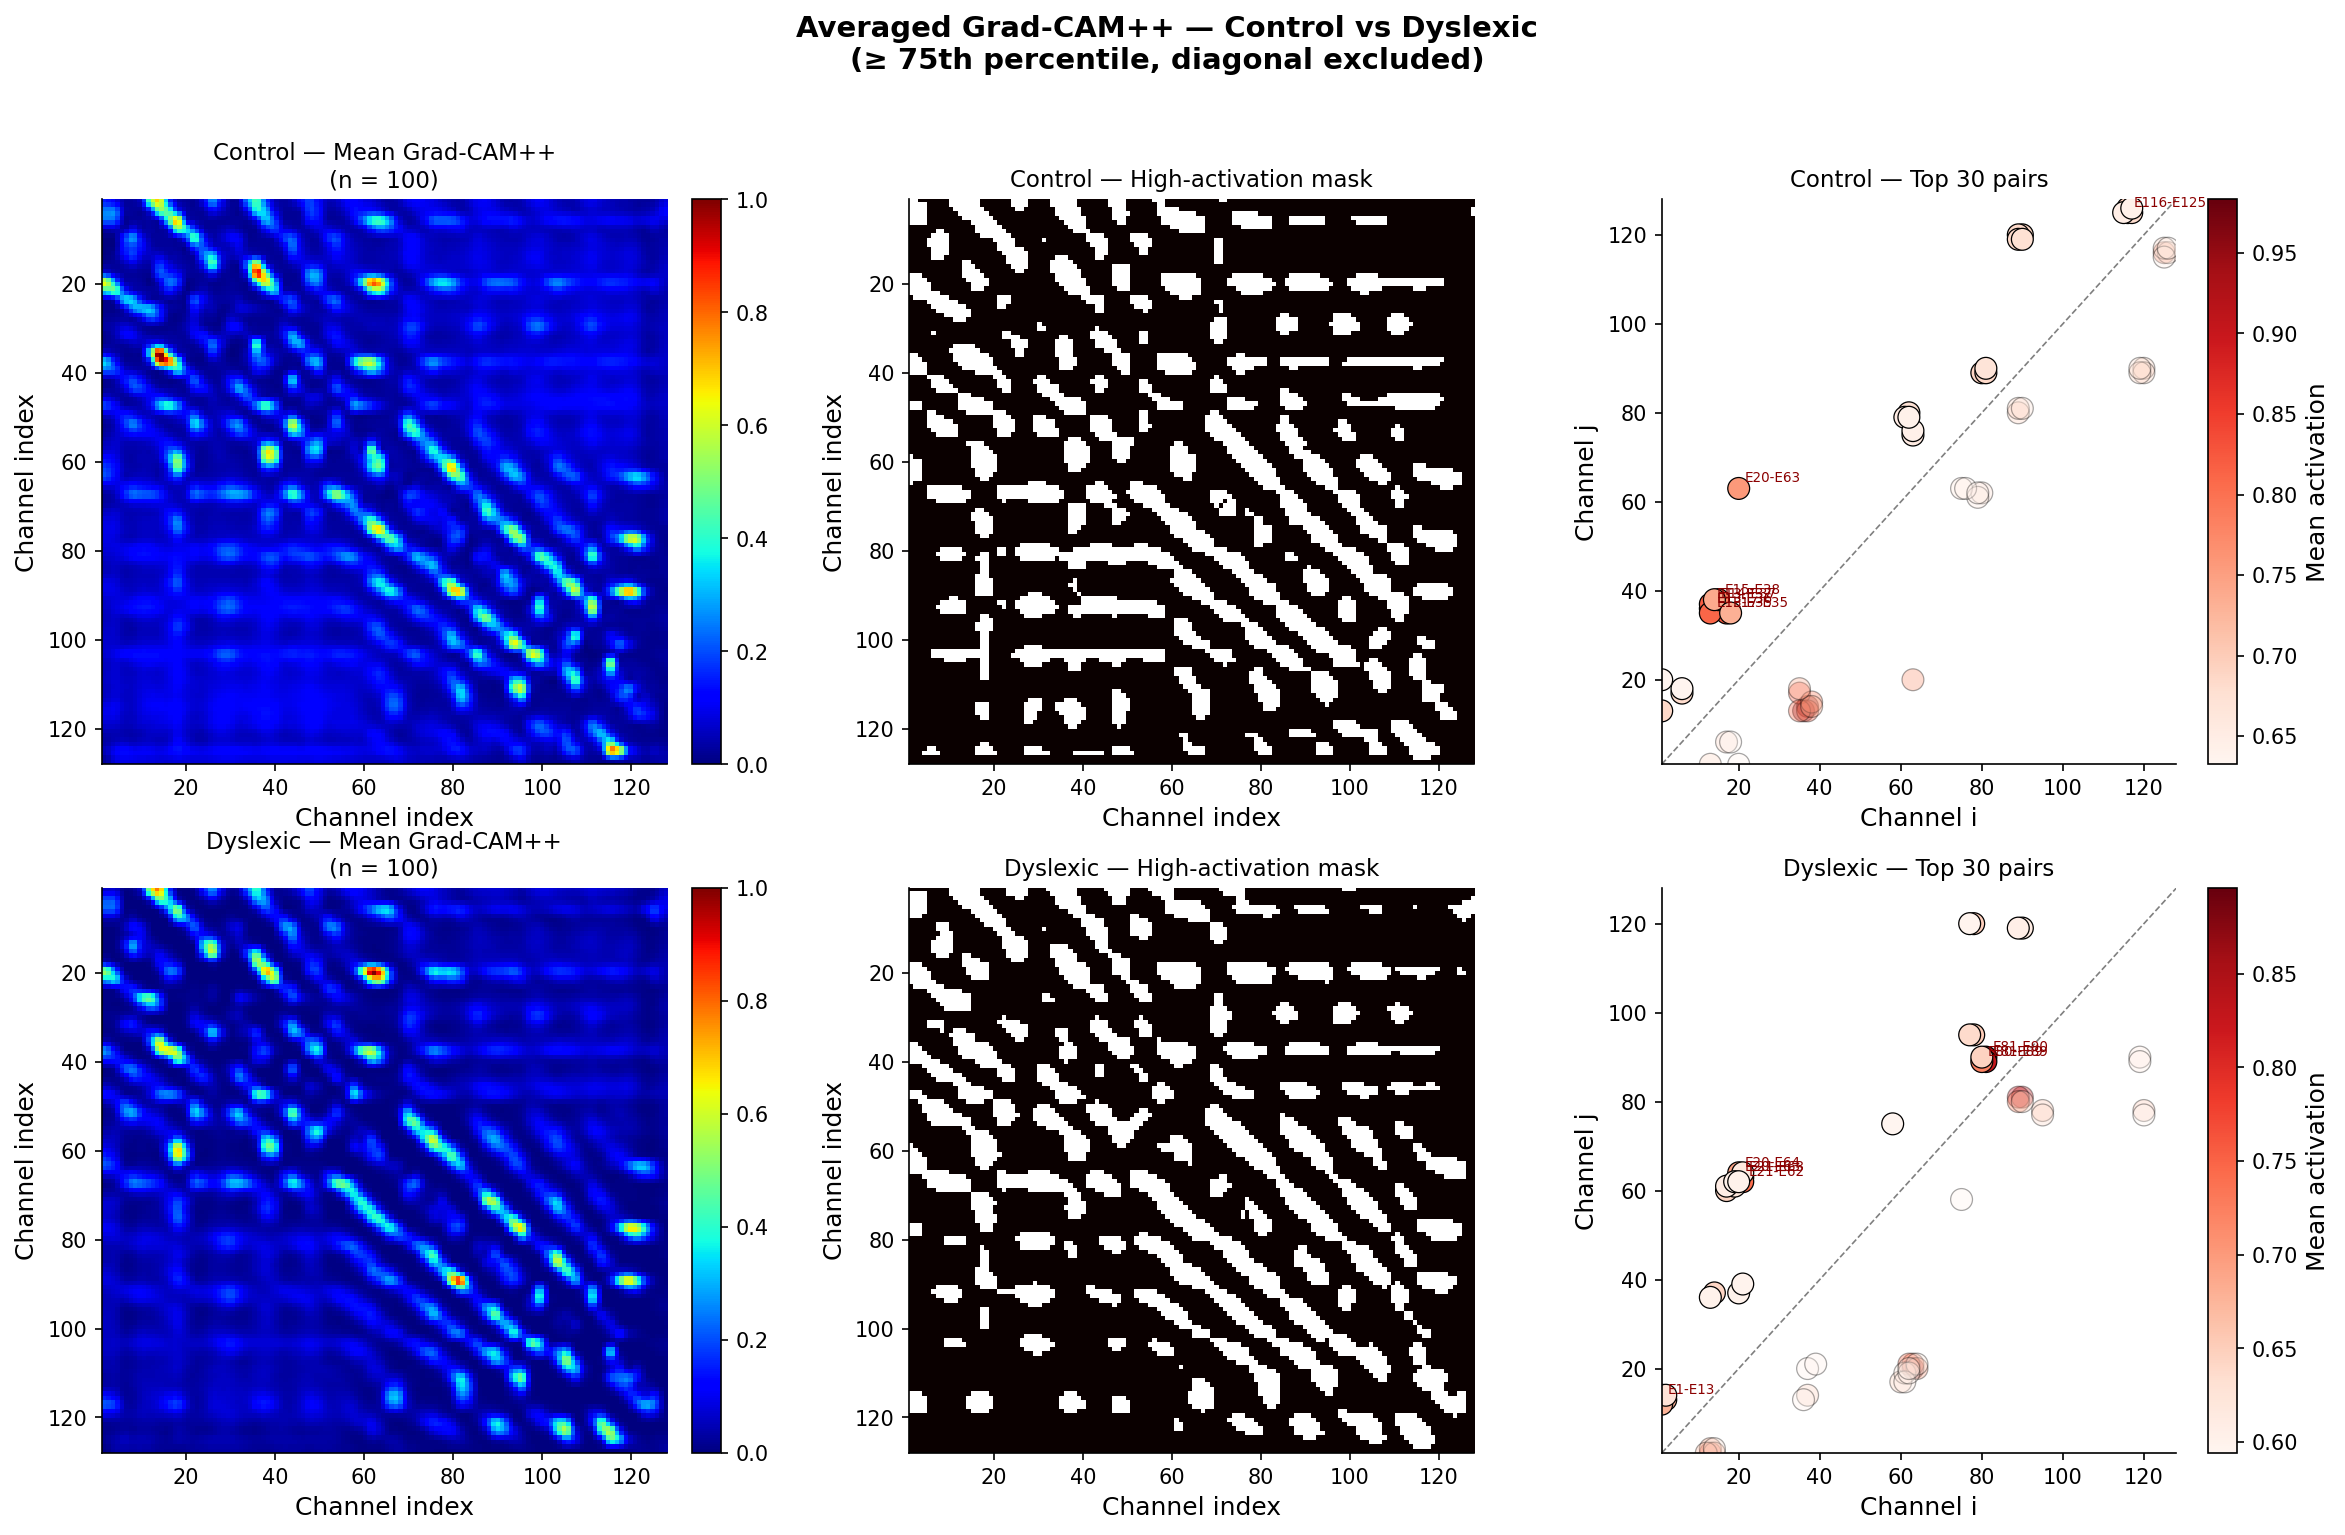

Saved → gradcam_averaged_channel_pairs.png / .pdf
Saved → channel_pairs_control.csv
Saved → channel_pairs_dyslexic.csv


In [7]:
# ============================================================
# Grad-CAM++ Analysis (adapted for Out-of-Fold setup)
# ============================================================
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
from collections import defaultdict
import csv

# -------------------- Config --------------------
img_rows, img_cols = 128, 128
N_CHANNELS = 128
TOP_N_PAIRS = 30
CAM_THRESHOLD = 0.75          # percentile
MAX_SAMPLES = 100             # per class (for speed)

# -------------------- Find correctly classified samples using OOF --------------------
model.eval()

correct_control_idx = []
correct_dyslexic_idx = []

y_true_oof = oof_true.astype(int)
y_pred_oof = (oof_prob > 0.5).astype(int)

for i in range(len(y_true_oof)):
    true_label = y_true_oof[i]
    pred_label = y_pred_oof[i]

    if pred_label == true_label == 0:
        correct_control_idx.append(i)
    elif pred_label == true_label == 1:
        correct_dyslexic_idx.append(i)

print(f"Correctly classified Control  : {len(correct_control_idx)}")
print(f"Correctly classified Dyslexic : {len(correct_dyslexic_idx)}")

if len(correct_control_idx) == 0 or len(correct_dyslexic_idx) == 0:
    raise ValueError("No correctly classified samples found for one of the classes. "
                     "Cannot compute class-specific Grad-CAM++.")

# -------------------- Grad-CAM++ class --------------------
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._fwd = target_layer.register_forward_hook(self._save_act)
        self._bwd = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out.detach()

    def _save_grad(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor):
        """Returns CAM (H,W) in [0,1], pred_label, pred_prob."""
        input_tensor = input_tensor.to(device)
        self.model.zero_grad()
        output = self.model(input_tensor)          # (1, 1)
        pred_prob = output.item()
        pred_label = int(pred_prob > 0.5)

        # Backward on the probability (works well for binary sigmoid)
        output.backward()

        A  = self.activations                      # (1, C, h, w)
        dS = self.gradients                        # (1, C, h, w)

        eps = 1e-7
        dS2 = dS ** 2
        dS3 = dS ** 3
        global_sum = A.sum(dim=(2, 3), keepdim=True)
        alpha = dS2 / (2.0 * dS2 + global_sum * dS3 + eps)
        weights = (alpha * F.relu(dS)).sum(dim=(2, 3))   # (1, C)

        cam = (weights[:, :, None, None] * A).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()

        # Normalize to [0, 1]
        c_min, c_max = cam.min(), cam.max()
        cam = (cam - c_min) / (c_max - c_min + eps)
        return cam, pred_label, pred_prob

    def remove_hooks(self):
        self._fwd.remove()
        self._bwd.remove()

# -------------------- Helper --------------------
def pixel_to_channel(r, c, img_h=img_rows, img_w=img_cols, n_ch=N_CHANNELS):
    ch_row = int(r / img_h * n_ch) + 1
    ch_col = int(c / img_w * n_ch) + 1
    return ch_row, ch_col

# -------------------- Accumulate CAMs --------------------
print("=" * 60)
print("Computing averaged Grad-CAM++ maps")
print("=" * 60)

gradcam_pp = GradCAMPlusPlus(model, target_layer=model.conv5)
model.eval()

np.random.seed(42)
ctrl_indices = np.random.choice(
    correct_control_idx,
    size=min(MAX_SAMPLES, len(correct_control_idx)),
    replace=False
)
dys_indices = np.random.choice(
    correct_dyslexic_idx,
    size=min(MAX_SAMPLES, len(correct_dyslexic_idx)),
    replace=False
)

def accumulate_cams(indices, class_name):
    cam_sum = np.zeros((img_rows, img_cols), dtype=np.float64)
    n_success = 0

    for i, idx in enumerate(indices):
        img_tensor = X_t[idx].unsqueeze(0).float()      # (1, 3, H, W)
        try:
            cam, _, _ = gradcam_pp.generate(img_tensor)
            cam_up = cv2.resize(cam, (img_cols, img_rows),
                                interpolation=cv2.INTER_LINEAR)
            cam_sum += cam_up
            n_success += 1
        except Exception as e:
            print(f"  [warn] sample {idx} failed: {e}")

        if (i + 1) % 20 == 0:
            print(f"  {class_name}: {i+1}/{len(indices)} processed")

    mean_cam = cam_sum / max(n_success, 1)
    mn, mx = mean_cam.min(), mean_cam.max()
    mean_cam = (mean_cam - mn) / (mx - mn + 1e-7)

    print(f"  {class_name}: finished ({n_success} successful CAMs)")
    return mean_cam

print(f"\nProcessing {len(ctrl_indices)} Control samples …")
mean_cam_ctrl = accumulate_cams(ctrl_indices, "Control")

print(f"\nProcessing {len(dys_indices)} Dyslexic samples …")
mean_cam_dys = accumulate_cams(dys_indices, "Dyslexic")

gradcam_pp.remove_hooks()
print("Hooks removed.")

# -------------------- Extract channel pairs --------------------
print("\n" + "=" * 60)
print("Extracting discriminative channel pairs")
print("=" * 60)

def extract_channel_pairs(mean_cam, threshold_percentile=CAM_THRESHOLD*100, top_n=TOP_N_PAIRS):
    threshold = np.percentile(mean_cam, threshold_percentile)
    binary_mask = (mean_cam >= threshold).astype(np.uint8)

    pair_activation = defaultdict(list)
    ys, xs = np.where(binary_mask)

    for r, c in zip(ys, xs):
        ch_i, ch_j = pixel_to_channel(r, c)
        if ch_i == ch_j:
            continue
        key = (min(ch_i, ch_j), max(ch_i, ch_j))
        pair_activation[key].append(mean_cam[r, c])

    ranked = sorted(
        [(f"E{k[0]}", f"E{k[1]}", float(np.mean(v)))
         for k, v in pair_activation.items()],
        key=lambda x: x[2], reverse=True
    )
    return ranked[:top_n], binary_mask, threshold

ctrl_pairs, ctrl_mask, _ = extract_channel_pairs(mean_cam_ctrl)
dys_pairs,  dys_mask,  _ = extract_channel_pairs(mean_cam_dys)

def print_pairs(pairs, name):
    print(f"\nTop {len(pairs)} pairs — {name}")
    print(f"{'Rank':<6} {'Ch_i':<8} {'Ch_j':<8} {'Mean CAM':<10}")
    print("-" * 36)
    for rank, (ci, cj, act) in enumerate(pairs, 1):
        print(f"{rank:<6} {ci:<8} {cj:<8} {act:.4f}")

print_pairs(ctrl_pairs, "CONTROL")
print_pairs(dys_pairs,  "DYSLEXIC")

# Unique / shared pairs
ctrl_set = {(p[0], p[1]) for p in ctrl_pairs}
dys_set  = {(p[0], p[1]) for p in dys_pairs}

print(f"\nUnique to Control  : {len(ctrl_set - dys_set)}")
print(f"Unique to Dyslexic : {len(dys_set - ctrl_set)}")
print(f"Shared pairs       : {len(ctrl_set & dys_set)}")

# -------------------- Visualization --------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Averaged Grad-CAM++ — Control vs Dyslexic\n"
             f"(≥ {CAM_THRESHOLD*100:.0f}th percentile, diagonal excluded)",
             fontsize=14, fontweight="bold", y=1.02)

class_data = [
    ("Control",  mean_cam_ctrl, ctrl_mask, ctrl_pairs, len(ctrl_indices)),
    ("Dyslexic", mean_cam_dys,  dys_mask,  dys_pairs,  len(dys_indices)),
]

for row, (cname, mean_cam, mask, pairs, n_samp) in enumerate(class_data):
    # 1. Mean CAM
    ax = axes[row, 0]
    im = ax.imshow(mean_cam, cmap="jet", vmin=0, vmax=1,
                   extent=[1, N_CHANNELS, N_CHANNELS, 1])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"{cname} — Mean Grad-CAM++\n(n = {n_samp})", fontsize=11)
    ax.set_xlabel("Channel index")
    ax.set_ylabel("Channel index")

    # 2. Thresholded mask
    ax = axes[row, 1]
    ax.imshow(mask, cmap="hot", vmin=0, vmax=1,
              extent=[1, N_CHANNELS, N_CHANNELS, 1])
    ax.set_title(f"{cname} — High-activation mask", fontsize=11)
    ax.set_xlabel("Channel index")
    ax.set_ylabel("Channel index")

    # 3. Top pairs scatter
    ax = axes[row, 2]
    if pairs:
        ci = [int(p[0][1:]) for p in pairs]
        cj = [int(p[1][1:]) for p in pairs]
        strengths = [p[2] for p in pairs]
        sc = ax.scatter(ci, cj, c=strengths, cmap="Reds", s=110,
                        edgecolors="k", linewidths=0.6,
                        vmin=min(strengths), vmax=max(strengths))
        ax.scatter(cj, ci, c=strengths, cmap="Reds", s=110,
                   edgecolors="k", linewidths=0.6, alpha=0.35,
                   vmin=min(strengths), vmax=max(strengths))
        plt.colorbar(sc, ax=ax, label="Mean activation")
        for p in pairs[:8]:
            ax.annotate(f"{p[0]}-{p[1]}", (int(p[0][1:]), int(p[1][1:])),
                        textcoords="offset points", xytext=(3, 3),
                        fontsize=6.5, color="darkred")

    ax.plot([1, N_CHANNELS], [1, N_CHANNELS], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(1, N_CHANNELS)
    ax.set_ylim(1, N_CHANNELS)
    ax.set_xlabel("Channel i")
    ax.set_ylabel("Channel j")
    ax.set_title(f"{cname} — Top {TOP_N_PAIRS} pairs", fontsize=11)

plt.tight_layout()
plt.savefig("gradcam_averaged_channel_pairs.png", dpi=300, bbox_inches="tight")
plt.savefig("gradcam_averaged_channel_pairs.pdf", bbox_inches="tight")
plt.show()
print("Saved → gradcam_averaged_channel_pairs.png / .pdf")

# -------------------- Export CSVs --------------------
for class_name, pairs in [("Control", ctrl_pairs), ("Dyslexic", dys_pairs)]:
    fname = f"channel_pairs_{class_name.lower()}.csv"
    with open(fname, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Rank", "Channel_i", "Channel_j", "Mean_CAM_Activation", "Class"])
        for rank, (ci, cj, act) in enumerate(pairs, 1):
            writer.writerow([rank, ci, cj, f"{act:.6f}", class_name])
    print(f"Saved → {fname}")

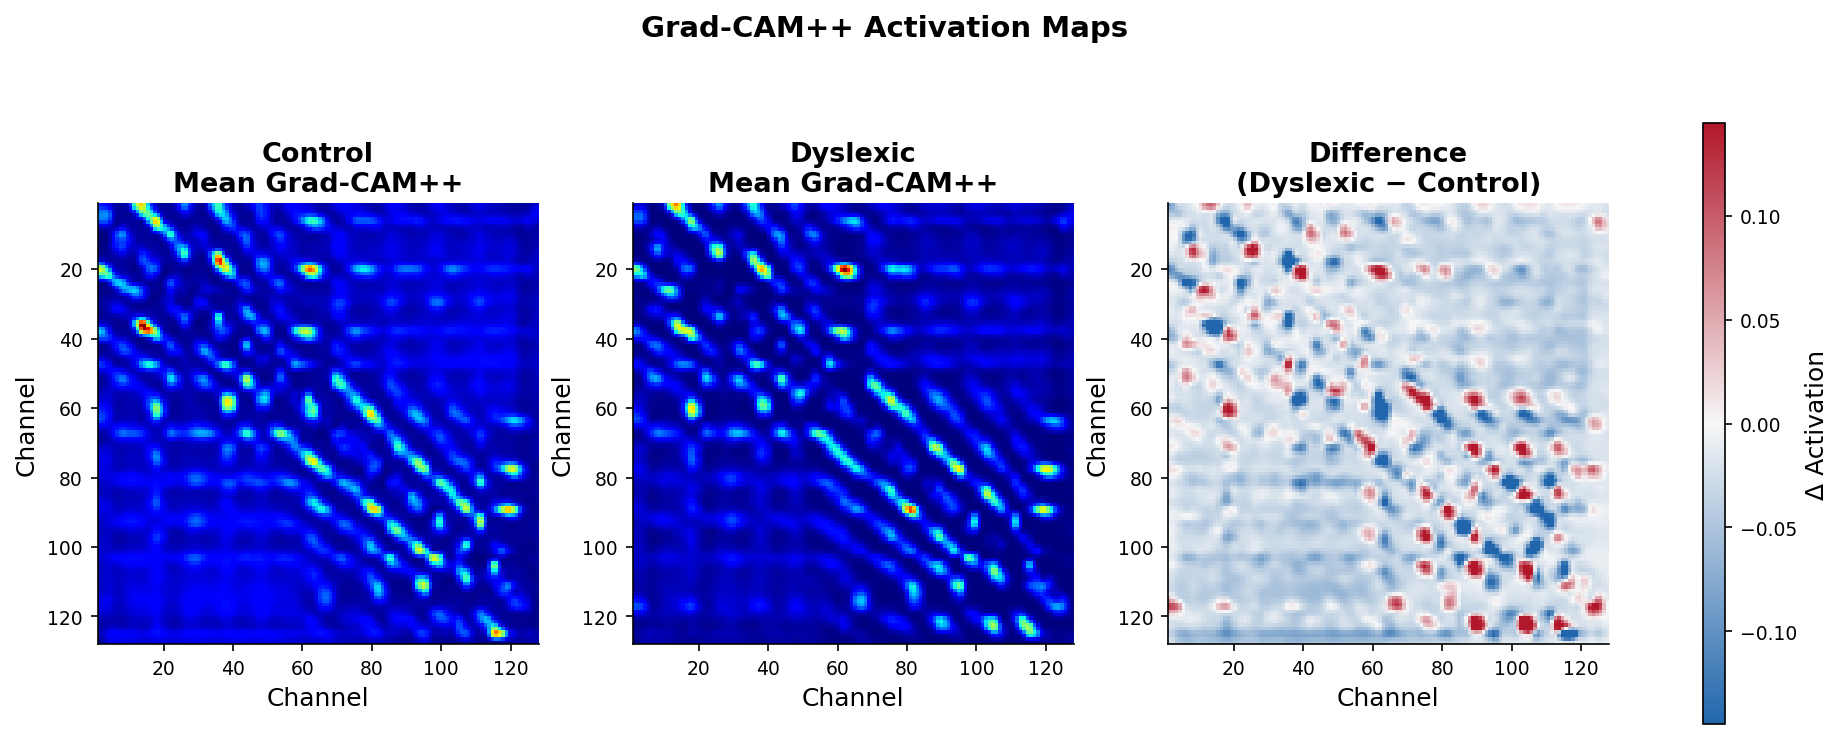

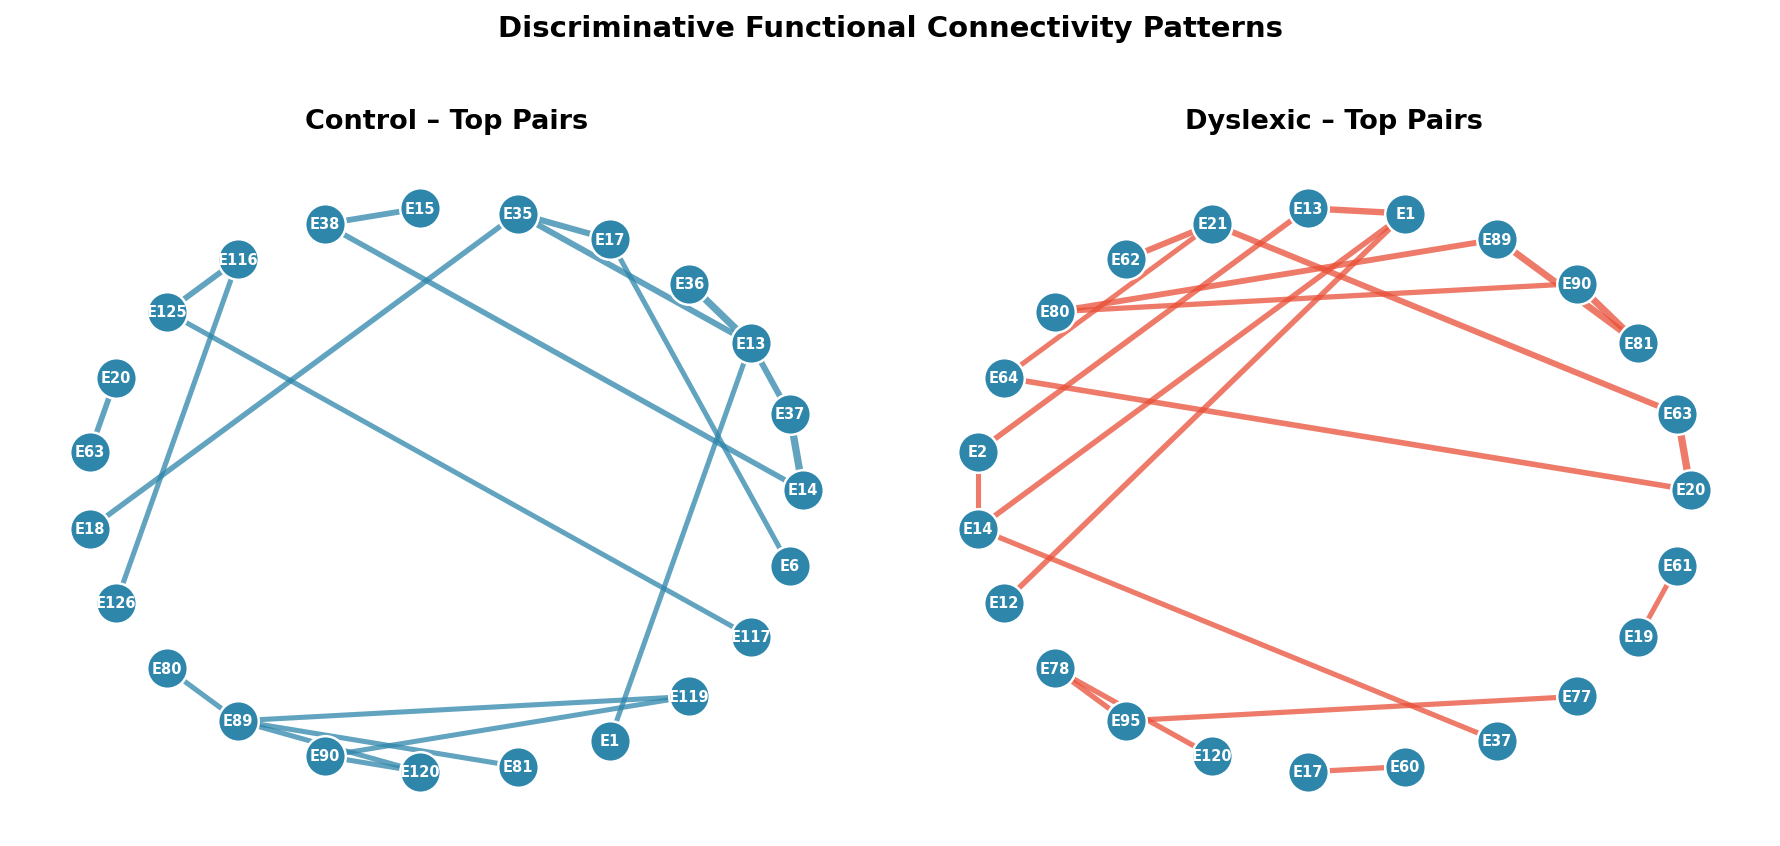

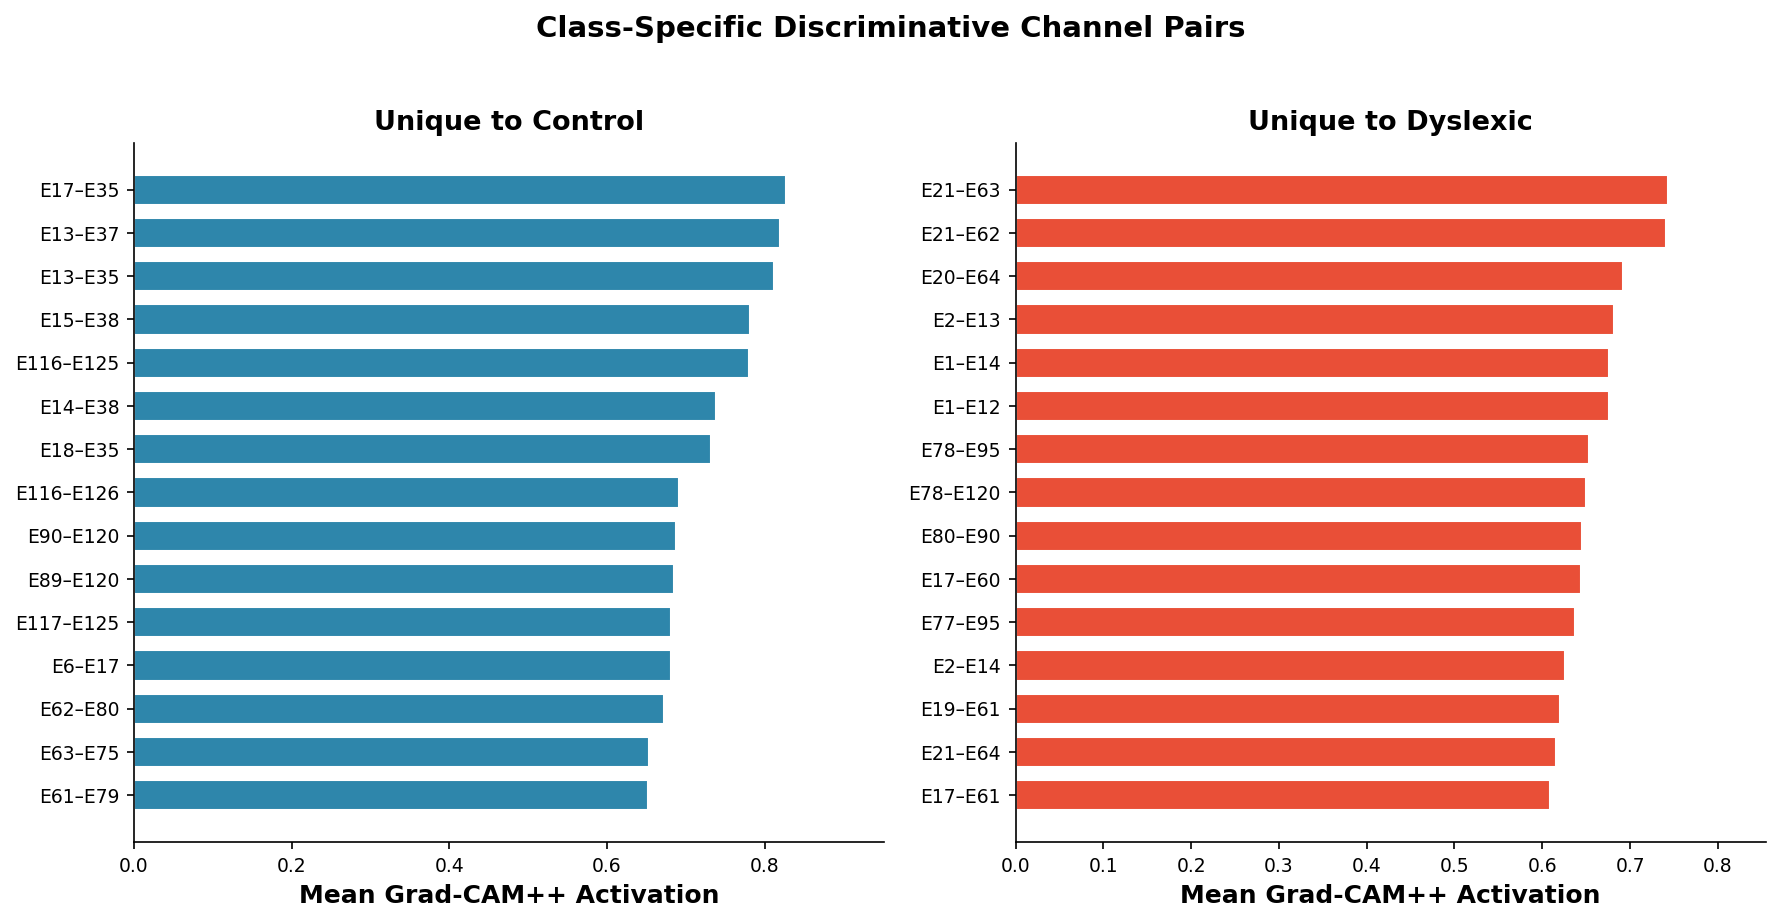

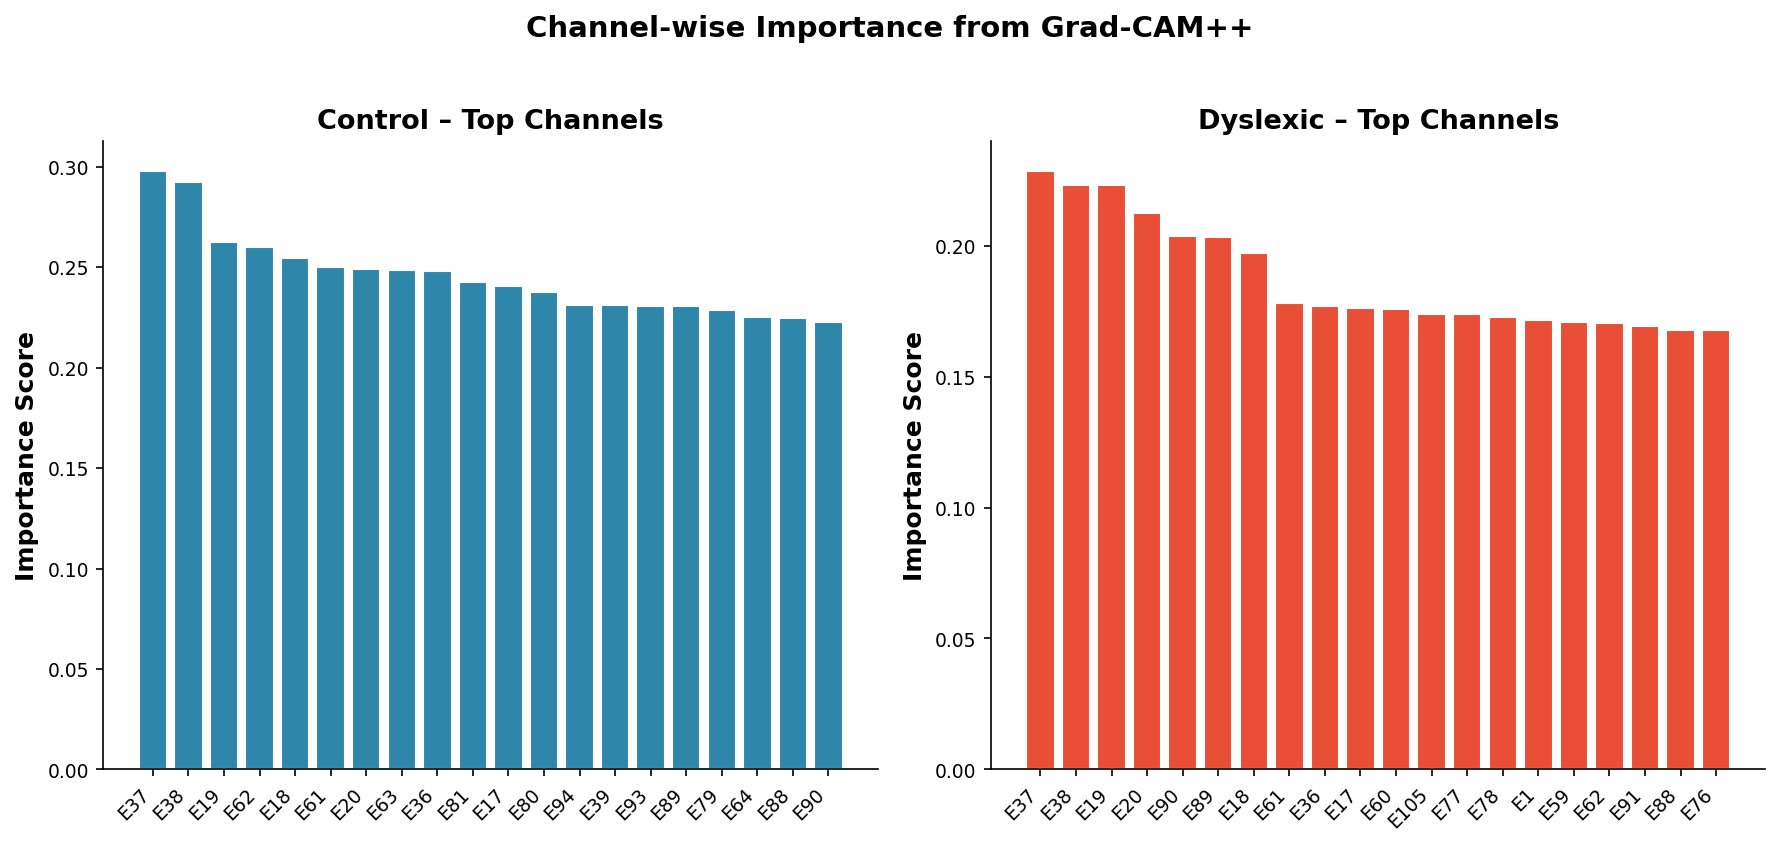

Generating qualitative overlays...


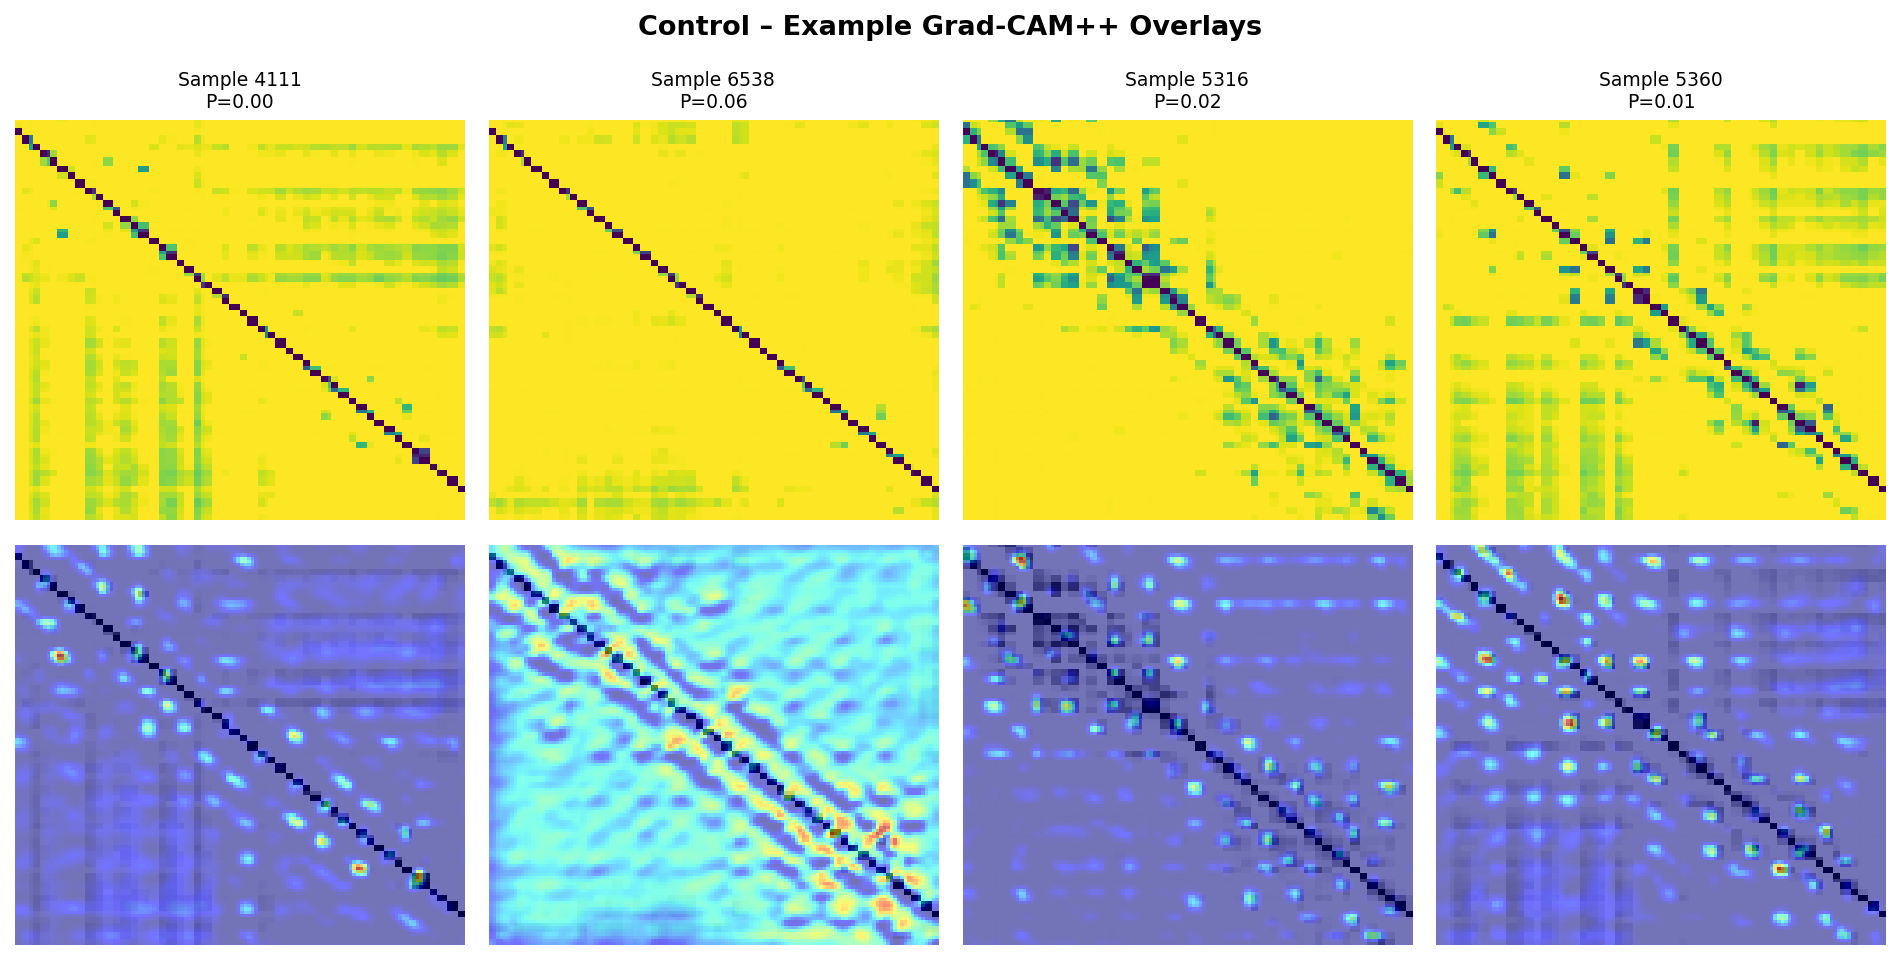

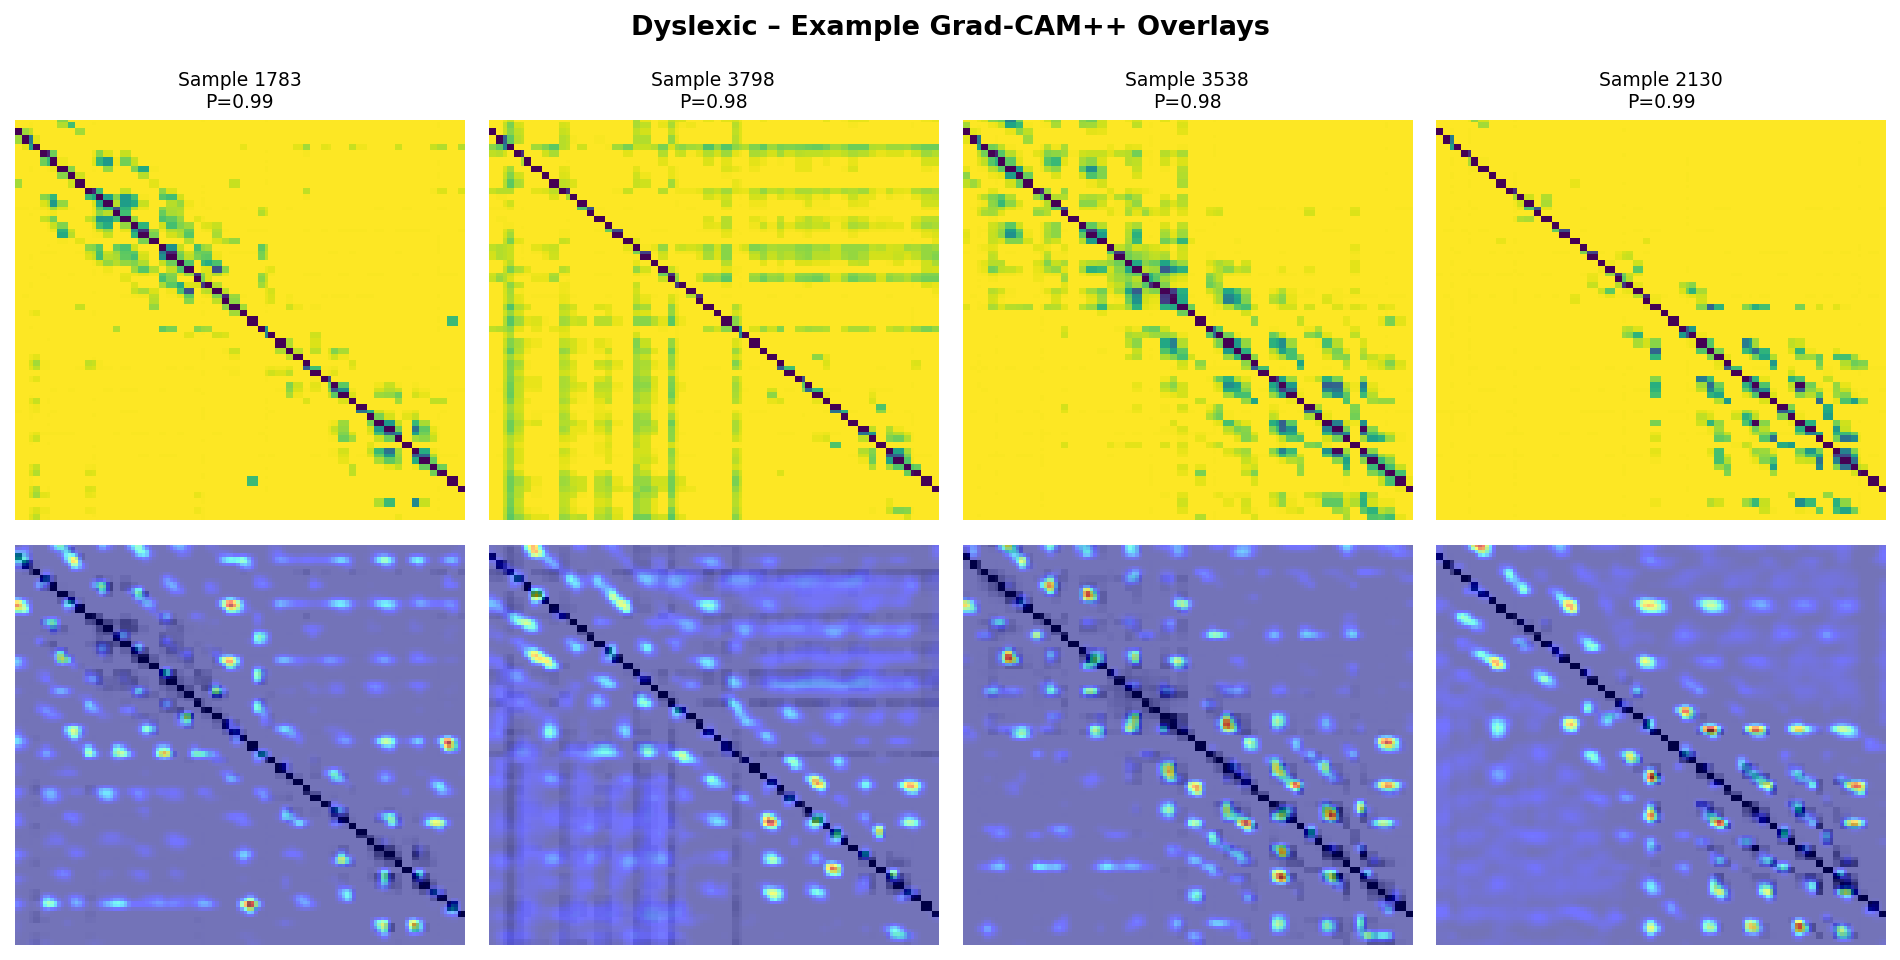


All advanced Grad-CAM++ figures saved (PNG 300 dpi + PDF).


In [8]:
# ============================================================
# ADVANCED GRAD-CAM++ VISUALIZATIONS
# Adapted for Out-of-Fold setup
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
from collections import defaultdict
import pandas as pd
import cv2

# ---------- Journal style ----------
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Custom colormaps
cmap_cam = "jet"
cmap_diff = LinearSegmentedColormap.from_list(
    "diverging", ["#2166ac", "#f7f7f7", "#b2182b"]
)

# ============================================================
# FIGURE A – Mean CAMs + Difference Map
# ============================================================
fig = plt.figure(figsize=(14, 5.2))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.28)

# Control
ax0 = fig.add_subplot(gs[0])
im0 = ax0.imshow(mean_cam_ctrl, cmap=cmap_cam, vmin=0, vmax=1,
                 extent=[1, N_CHANNELS, N_CHANNELS, 1])
ax0.set_title("Control\nMean Grad-CAM++", fontweight="bold")
ax0.set_xlabel("Channel")
ax0.set_ylabel("Channel")

# Dyslexic
ax1 = fig.add_subplot(gs[1])
im1 = ax1.imshow(mean_cam_dys, cmap=cmap_cam, vmin=0, vmax=1,
                 extent=[1, N_CHANNELS, N_CHANNELS, 1])
ax1.set_title("Dyslexic\nMean Grad-CAM++", fontweight="bold")
ax1.set_xlabel("Channel")
ax1.set_ylabel("Channel")

# Difference (Dys – Control)
diff_cam = mean_cam_dys - mean_cam_ctrl
vmax = np.percentile(np.abs(diff_cam), 98)
ax2 = fig.add_subplot(gs[2])
im2 = ax2.imshow(diff_cam, cmap=cmap_diff, vmin=-vmax, vmax=vmax,
                 extent=[1, N_CHANNELS, N_CHANNELS, 1])
ax2.set_title("Difference\n(Dyslexic − Control)", fontweight="bold")
ax2.set_xlabel("Channel")
ax2.set_ylabel("Channel")

# Colorbar
cax = fig.add_subplot(gs[3])
plt.colorbar(im2, cax=cax, label="Δ Activation")

plt.suptitle("Grad-CAM++ Activation Maps", fontsize=14, fontweight="bold", y=1.02)
plt.savefig("figA_gradcam_heatmaps_diff.png", dpi=300)
plt.savefig("figA_gradcam_heatmaps_diff.pdf")
plt.show()

# ============================================================
# FIGURE B – Network Graphs of Top Channel Pairs
# ============================================================
def plot_connectivity_network(pairs, title, ax, color="#E94F37"):
    G = nx.Graph()
    for ci, cj, weight in pairs[:20]:  # top 20
        G.add_edge(ci, cj, weight=weight)

    pos = nx.circular_layout(G)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(weights) if weights else 1

    nx.draw_networkx_nodes(G, pos, node_size=380, node_color="#2E86AB",
                           edgecolors="white", linewidths=1.2, ax=ax)
    nx.draw_networkx_edges(G, pos,
                           width=[w / max_w * 3.5 for w in weights],
                           edge_color=color, alpha=0.75, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, font_color="white",
                            font_weight="bold", ax=ax)
    ax.set_title(title, fontweight="bold", pad=10)
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
plot_connectivity_network(ctrl_pairs, "Control – Top Pairs", axes[0], color="#2E86AB")
plot_connectivity_network(dys_pairs,  "Dyslexic – Top Pairs", axes[1], color="#E94F37")

plt.suptitle("Discriminative Functional Connectivity Patterns",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figB_channel_pair_networks.png", dpi=300)
plt.savefig("figB_channel_pair_networks.pdf")
plt.show()

# ============================================================
# FIGURE C – Ranked Unique Pairs (Horizontal bars)
# ============================================================
def get_unique_with_strength(unique_set, pairs):
    strength_dict = {(p[0], p[1]): p[2] for p in pairs}
    result = []
    for pair in unique_set:
        if pair in strength_dict:
            result.append((f"{pair[0]}–{pair[1]}", strength_dict[pair]))
    return sorted(result, key=lambda x: x[1], reverse=True)[:15]

ctrl_unique_str = get_unique_with_strength(ctrl_set - dys_set, ctrl_pairs)
dys_unique_str  = get_unique_with_strength(dys_set - ctrl_set, dys_pairs)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Control unique
if ctrl_unique_str:
    names, vals = zip(*ctrl_unique_str)
    axes[0].barh(names[::-1], vals[::-1], color="#2E86AB", edgecolor="white", height=0.7)
    axes[0].set_xlim(0, max(vals) * 1.15)
else:
    axes[0].text(0.5, 0.5, "No unique pairs", ha="center", va="center")
axes[0].set_xlabel("Mean Grad-CAM++ Activation", fontweight="bold")
axes[0].set_title("Unique to Control", fontweight="bold")

# Dyslexic unique
if dys_unique_str:
    names, vals = zip(*dys_unique_str)
    axes[1].barh(names[::-1], vals[::-1], color="#E94F37", edgecolor="white", height=0.7)
    axes[1].set_xlim(0, max(vals) * 1.15)
else:
    axes[1].text(0.5, 0.5, "No unique pairs", ha="center", va="center")
axes[1].set_xlabel("Mean Grad-CAM++ Activation", fontweight="bold")
axes[1].set_title("Unique to Dyslexic", fontweight="bold")

plt.suptitle("Class-Specific Discriminative Channel Pairs",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figC_unique_pairs_bars.png", dpi=300)
plt.savefig("figC_unique_pairs_bars.pdf")
plt.show()

# ============================================================
# FIGURE D – Channel Importance Ranking
# ============================================================
def compute_channel_importance(mean_cam, n_ch=N_CHANNELS):
    """Sum of activation for each channel (row + column)."""
    importance = np.zeros(n_ch)
    h, w = mean_cam.shape
    for i in range(n_ch):
        r_start = int(i * h / n_ch)
        r_end   = int((i + 1) * h / n_ch)
        c_start = int(i * w / n_ch)
        c_end   = int((i + 1) * w / n_ch)
        importance[i] = mean_cam[r_start:r_end, :].mean() + mean_cam[:, c_start:c_end].mean()
    return importance

imp_ctrl = compute_channel_importance(mean_cam_ctrl)
imp_dys  = compute_channel_importance(mean_cam_dys)

top_k = 20
idx_ctrl = np.argsort(imp_ctrl)[-top_k:][::-1]
idx_dys  = np.argsort(imp_dys)[-top_k:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].bar(range(top_k), imp_ctrl[idx_ctrl], color="#2E86AB", edgecolor="white")
axes[0].set_xticks(range(top_k))
axes[0].set_xticklabels([f"E{i+1}" for i in idx_ctrl], rotation=45, ha="right")
axes[0].set_ylabel("Importance Score", fontweight="bold")
axes[0].set_title("Control – Top Channels", fontweight="bold")

axes[1].bar(range(top_k), imp_dys[idx_dys], color="#E94F37", edgecolor="white")
axes[1].set_xticks(range(top_k))
axes[1].set_xticklabels([f"E{i+1}" for i in idx_dys], rotation=45, ha="right")
axes[1].set_ylabel("Importance Score", fontweight="bold")
axes[1].set_title("Dyslexic – Top Channels", fontweight="bold")

plt.suptitle("Channel-wise Importance from Grad-CAM++",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figD_channel_importance.png", dpi=300)
plt.savefig("figD_channel_importance.pdf")
plt.show()

# ============================================================
# FIGURE E – Example Overlays (Qualitative)
# ============================================================
def show_overlay_examples(indices, class_name, n_show=4):
    fig, axes = plt.subplots(2, n_show, figsize=(3.2 * n_show, 6.5))

    for i, idx in enumerate(indices[:n_show]):
        # Original connectivity matrix
        img = X_t[idx].cpu().numpy()          # (3, H, W)
        img_gray = img.mean(axis=0)           # simple grayscale version

        # CAM for this sample
        img_tensor = X_t[idx].unsqueeze(0).float()
        cam, _, prob = gradcam_pp.generate(img_tensor)
        cam_up = cv2.resize(cam, (img_cols, img_rows))

        # Row 0: original
        axes[0, i].imshow(img_gray, cmap="viridis", aspect="auto")
        axes[0, i].set_title(f"Sample {idx}\nP={prob:.2f}", fontsize=9)
        axes[0, i].axis("off")

        # Row 1: overlay
        axes[1, i].imshow(img_gray, cmap="gray", aspect="auto")
        axes[1, i].imshow(cam_up, cmap="jet", alpha=0.55, aspect="auto")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontweight="bold")
    axes[1, 0].set_ylabel("Grad-CAM++ Overlay", fontweight="bold")
    plt.suptitle(f"{class_name} – Example Grad-CAM++ Overlays",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"figE_overlays_{class_name.lower()}.png", dpi=300)
    plt.savefig(f"figE_overlays_{class_name.lower()}.pdf")
    plt.show()

# Re-create GradCAM object (hooks were removed earlier)
gradcam_pp = GradCAMPlusPlus(model, target_layer=model.conv5)

print("Generating qualitative overlays...")
show_overlay_examples(ctrl_indices, "Control",  n_show=4)
show_overlay_examples(dys_indices,  "Dyslexic", n_show=4)

gradcam_pp.remove_hooks()
print("\nAll advanced Grad-CAM++ figures saved (PNG 300 dpi + PDF).")